## Backtesting de Estrategia de Scalping
Este código que me ha dado copilot, realiza el backtesting de una estrategia de Scalping basada en EMAs

In [1]:
# importar las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from binance.client import Client
from ta.trend import EMAIndicator
import os


Para conectarme a la API de Binance necesito dos claves: La apiKey y la clave secreta.
Esta conexión se hace usando las variables de entorno del sistema BINANCE_API_KEY y BINANCE_SECRET_KEY

In [2]:
# configurar las claves API de Binance
claveApi = os.getenv("BINANCE_API_KEY")
secreta = os.getenv("BINANCE_SECRET_KEY")

# verificar si las claves se cargaron correctamente
if not claveApi or not secreta:
    raise ValueError("Las claves API de BINANCE no están configuradas correctamente")


In [3]:
# realizar y chequear la conexión con la API de Binance
try:
   cliente = Client(claveApi, secreta)
   print("Conexión exitosa con Binance")
except Exception as e:
   print(f"Error al conectar con Binance: {e}")

Conexión exitosa con Binance


Una vez establecida la conexión con la API de binance, se van obtener los datos de precios históricos del ticker deseado, Para esto es necesario pasarle algunos parámetros a la instancia __cliente__ antes creada. Estos parámetros son:
1. El ticker o símbolo

2. El intervalo. Algunos de los intervalos disponibles son:
Client.KLINE_INTERVAL_1MINUTE (1 minuto)
Client.KLINE_INTERVAL_3MINUTE (3 minutos)
Client.KLINE_INTERVAL_5MINUTE (5 minutos)
Client.KLINE_INTERVAL_15MINUTE (15 minutos)
Client.KLINE_INTERVAL_30MINUTE (30 minutos)
Client.KLINE_INTERVAL_1HOUR (1 hora)
Client.KLINE_INTERVAL_2HOUR (2 horas)
Client.KLINE_INTERVAL_4HOUR (4 horas)
Client.KLINE_INTERVAL_6HOUR (6 horas)
Client.KLINE_INTERVAL_8HOUR (8 horas)
Client.KLINE_INTERVAL_12HOUR (12 horas)
Client.KLINE_INTERVAL_1DAY (1 día)
Client.KLINE_INTERVAL_3DAY (3 días)
Client.KLINE_INTERVAL_1WEEK (1 semana)
Client.KLINE_INTERVAL_1MONTH (1 mes)

3. Las fechas de inicio y fin de los precios que se quieren agarrar


In [4]:
def obtener_datos(symbol, intervalo, fecha_inicio, fecha_fin):
    # obtener datos históricos del ticker establecido
    historico = cliente.get_historical_klines(symbol, intervalo, fecha_inicio, fecha_fin)
    # convertir histórico en dataframe
    historico_df = pd.DataFrame(historico, columns=['Open time', 'Open', 'High',
                    'Low', 'Close', 'Volume', 'Close time', 'QA volume', 
                    'Number of trades', 'TB base volumen', 'TB Quote volumen', 'Ignore'])
    # convertir los timestamps a formato de fecha y hora
    historico_df['Close time'] = pd.to_datetime(historico_df['Close time'], unit = 'ms')
    # selecionar  las columnas que se van a guardar en el archivo CSV
    historico_df = historico_df[['Close time', 'Open', 'High', 'Low','Close', 'Volume']]
    historico_df = historico_df.rename(columns = {"Close time": "Date"})
    # convertir la columna "price" a numérico
    historico_df["Open"] = pd.to_numeric(historico_df["Open"])
    historico_df["High"] = pd.to_numeric(historico_df["High"])
    historico_df["Low"] = pd.to_numeric(historico_df["Low"])
    historico_df["Close"] = pd.to_numeric(historico_df["Close"])
    
    return historico_df


In [5]:
# establecer el símbolo del ticker que se quiere analizar
symbol = 'SOLUSDT'

# intervalo de tiempo para los datos hist´ricos
intervalo = Client.KLINE_INTERVAL_5MINUTE

# fechas de inicio y fin para los datos históricos
fecha_inicio = '1 Jan 2023'
fecha_fin = '31 Dec 2023'

In [6]:
df = obtener_datos(symbol, intervalo, fecha_inicio, fecha_fin)

<Axes: title={'center': 'SOLUSDT tendencia de precio en 2023'}, xlabel='Fecha', ylabel='Precio'>

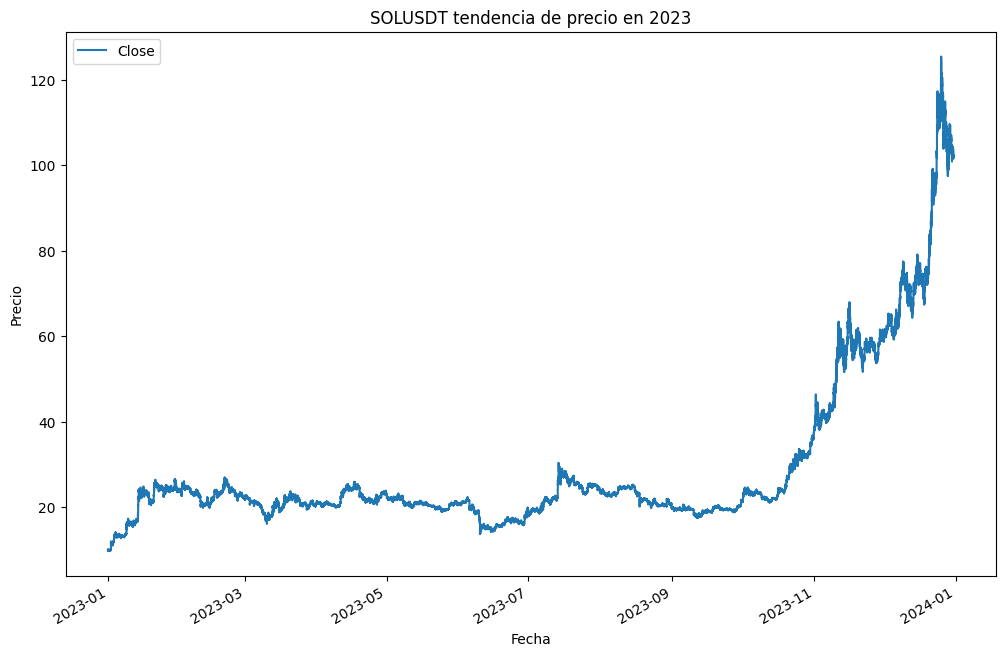

In [8]:
# para visualizar la tendencia graficamos los datos
df.plot(x="Date", y="Close", title="SOLUSDT tendencia de precio en 2023", 
                  xlabel="Fecha", ylabel="Precio", figsize=(12, 8))

In [9]:
# guardar el dataframe en un archivo CSV
df.to_csv('solusdt_2023_5min.csv', index=False)